# PTB-XL Model Comparison: S4 vs LMU

## Research Objective
Comprehensive evaluation of **S4 (Structured State Space)** vs **LMU (Legendre Memory Unit)** architectures for multi-label ECG classification on the PTB-XL dataset.

### Task: PTB-XL Multi-Label ECG Classification
- **Dataset:** PTB-XL (12-lead ECG time series)
- **Classes:** 5 superclasses [NORM, MI, STTC, HYP, CD]
- **Task Type:** Multi-label classification
- **Primary Metric:** F1-Micro (micro-averaged F1 score)

### Experimental Design
- **Models:** S4 vs LMU
- **Data Fractions:** 10%, 25%, 50%, 100%
- **Evaluation:** Test set generalization performance

---


In [1]:
# Environment Setup
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Any

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Pandas display settings
pd.options.display.float_format = '{:.4f}'.format
pd.options.display.max_rows = 100

print("✅ Environment setup complete")

✅ Environment setup complete


---
## 1. Load Experiment Results

Load all S4 and LMU experiment results including test metrics from saved checkpoints.


In [2]:
from src.eval.compare import load_all_experiments

# Configuration
base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "ptbxl"

print("=" * 70)
print("LOADING PTB-XL EXPERIMENT RESULTS")
print("=" * 70)
print()

# Load all results
all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("=" * 70)
print("LOADING SUMMARY")
print("=" * 70)

# Display loading summary
for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"  {model.upper():3s}: Loaded {n_loaded}/{len(fractions)} experiments")

print()


CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


LOADING PTB-XL EXPERIMENT RESULTS

📂 Loading S4 @ 10%: ptbxl_s4_task_frac_10
📂 Loading S4 @ 25%: ptbxl_s4_task_frac_25
📂 Loading S4 @ 50%: ptbxl_s4_task_frac_50
📂 Loading S4 @ 100%: ptbxl_s4_task
📂 Loading LMU @ 10%: ptbxl_lmu_task_frac_10
📂 Loading LMU @ 25%: ptbxl_lmu_task_frac_25
📂 Loading LMU @ 50%: ptbxl_lmu_task_frac_50
📂 Loading LMU @ 100%: ptbxl_lmu_task

LOADING SUMMARY
  S4 : Loaded 4/4 experiments
  LMU: Loaded 4/4 experiments



---
## 2. Test Metrics Comparison Table

Comprehensive pandas DataFrame showing test set F1-Micro scores for all model/fraction combinations.


In [5]:
rows = []

for model in sorted(all_results.keys()):
    for frac in sorted(all_results[model].keys()):
        results = all_results[model][frac]
        if not results:
            continue

        # Try to get F1-Micro from results
        f1_micro = results.get('test_f1_micro')

        # Fallback: load directly from test_results.json
        if f1_micro is None:
            checkpoint_path = Path(results.get('checkpoint_path', ''))
            if checkpoint_path.exists():
                test_results_path = checkpoint_path.parent / 'test_results.json'
                if test_results_path.exists():
                    with open(test_results_path) as f:
                        test_data = json.load(f)
                        f1_micro = test_data.get('f1_micro')

        if f1_micro is not None:
            row = {
                'model': model.upper(),
                'data_pct': int(frac * 100),
                'test_f1_micro': float(f1_micro),
                'num_samples': results.get('num_test_samples', 'N/A')
            }
            rows.append(row)

# Create DataFrame
test_comparison_df = pd.DataFrame(rows)

print("=" * 70)
print("TEST SET COMPARISON: F1-MICRO SCORES")
print("=" * 70)
print()
print(test_comparison_df.to_string(index=False))
print()

# Save to CSV
# csv_path = Path("./test_comparison_results.csv")
# test_comparison_df.to_csv(csv_path, index=False)
# print(f"✅ Results saved to: {csv_path}")
# print()

# Identify best model per fraction
print("=" * 70)
print("BEST MODEL PER DATA FRACTION")
print("=" * 70)

for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['test_f1_micro'].idxmax()
    best_row = subset.loc[best_idx]
    print(f"  {pct:3d}% data: {best_row['model']:3s} (F1-Micro: {best_row['test_f1_micro']:.4f})")

print()

# Overall best configuration
overall_best_idx = test_comparison_df['test_f1_micro'].idxmax()
overall_best = test_comparison_df.loc[overall_best_idx]
print("=" * 70)
print(f"🏆 OVERALL BEST: {overall_best['model']} at {overall_best['data_pct']}% data")
print(f"   F1-Micro: {overall_best['test_f1_micro']:.4f}")
print("=" * 70)


TEST SET COMPARISON: F1-MICRO SCORES

model  data_pct  test_f1_micro  num_samples
  LMU        10         0.6166         2203
  LMU        25         0.6586         2203
  LMU        50         0.6691         2203
  LMU       100         0.7103         2203
   S4        10         0.6360         2203
   S4        25         0.6799         2203
   S4        50         0.7012         2203
   S4       100         0.7283         2203

BEST MODEL PER DATA FRACTION
   10% data: S4  (F1-Micro: 0.6360)
   25% data: S4  (F1-Micro: 0.6799)
   50% data: S4  (F1-Micro: 0.7012)
  100% data: S4  (F1-Micro: 0.7283)

🏆 OVERALL BEST: S4 at 100% data
   F1-Micro: 0.7283


---
## 3. Visualization: Test F1-Micro Comparison

Bar chart comparing test set F1-Micro scores across models and data fractions.


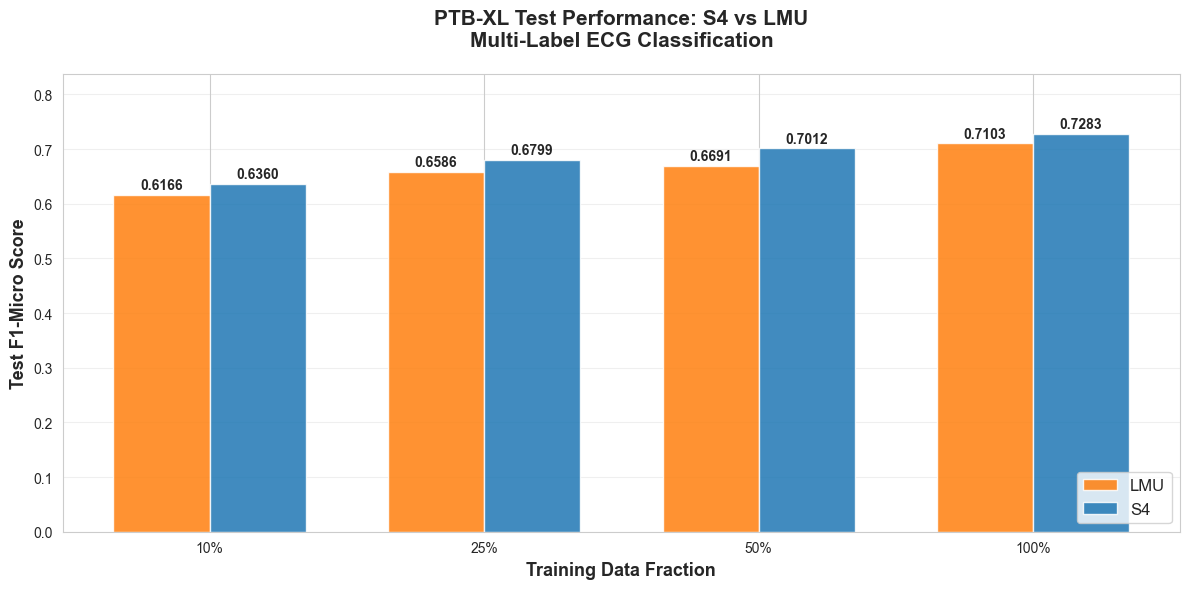

✅ Plot saved as: ptbxl_f1_comparison.png


In [6]:
# Prepare data for plotting
pivot_data = test_comparison_df.pivot(index='data_pct', columns='model', values='test_f1_micro')

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(pivot_data.index))
width = 0.35

colors = {'S4': '#1f77b4', 'LMU': '#ff7f0e'}

for i, model in enumerate(pivot_data.columns):
    values = pivot_data[model].values
    offset = width * (i - 0.5)
    bars = ax.bar(x + offset, values, width,
                  label=model,
                  alpha=0.85,
                  color=colors.get(model, '#2ca02c'))

    # Add value labels on bars
    for j, (bar, val) in enumerate(zip(bars, values)):
        if not np.isnan(val):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{val:.4f}',
                   ha='center', va='bottom',
                   fontsize=10, fontweight='bold')

ax.set_xlabel('Training Data Fraction', fontsize=13, fontweight='bold')
ax.set_ylabel('Test F1-Micro Score', fontsize=13, fontweight='bold')
ax.set_title('PTB-XL Test Performance: S4 vs LMU\nMulti-Label ECG Classification',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'{int(pct)}%' for pct in pivot_data.index])
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(pivot_data.max()) * 1.15)

plt.tight_layout()
plt.show()

---
## 4. Data Efficiency Analysis

Line plot showing how test performance scales with training data size. This reveals which model learns more efficiently from limited data.


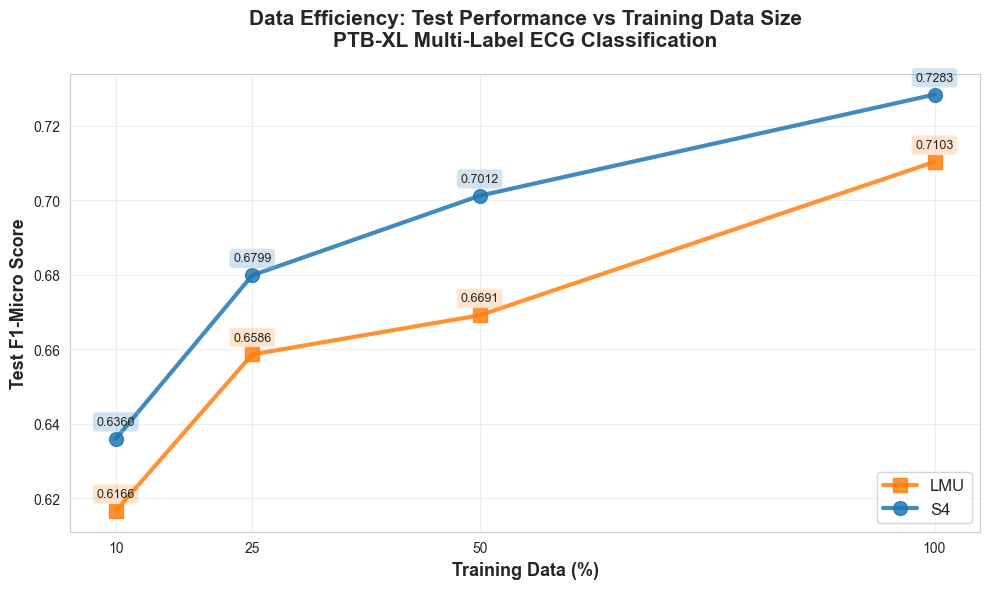

✅ Plot saved as: ptbxl_data_efficiency.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'S4': '#1f77b4', 'LMU': '#ff7f0e'}
markers = {'S4': 'o', 'LMU': 's'}

for model in pivot_data.columns:
    data = pivot_data[model].dropna()
    ax.plot(data.index, data.values,
           label=model,
           marker=markers.get(model, 'o'),
           markersize=10,
           linewidth=3,
           color=colors.get(model, '#2ca02c'),
           alpha=0.85)

    # Add value annotations
    for pct, val in zip(data.index, data.values):
        ax.annotate(f'{val:.4f}',
                   xy=(pct, val),
                   xytext=(0, 10),
                   textcoords='offset points',
                   ha='center',
                   fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.3',
                           facecolor=colors.get(model, '#2ca02c'),
                           alpha=0.2))

ax.set_xlabel('Training Data (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Test F1-Micro Score', fontsize=13, fontweight='bold')
ax.set_title('Data Efficiency: Test Performance vs Training Data Size\nPTB-XL Multi-Label ECG Classification',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xticks([10, 25, 50, 100])
ax.set_xlim(5, 105)

plt.tight_layout()
plt.show()

---
## 5. Detailed Comparison by Data Fraction

Breakdown showing winner at each fraction with performance margins.


In [9]:
print("=" * 70)
print("DETAILED COMPARISON BY DATA FRACTION")
print("=" * 70)
print()

for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct].copy()
    subset = subset.sort_values('test_f1_micro', ascending=False)

    print(f"📊 Training Data: {pct}%")
    print("-" * 70)

    for idx, row in subset.iterrows():
        print(f"  {row['model']:3s}: F1-Micro = {row['test_f1_micro']:.4f}")

    if len(subset) >= 2:
        best = subset.iloc[0]
        second = subset.iloc[1]
        margin = best['test_f1_micro'] - second['test_f1_micro']
        relative_margin = (margin / second['test_f1_micro']) * 100

        print()
        print(f"  🏆 Winner: {best['model']}")
        print(f"  📈 Margin: +{margin:.4f} absolute (+{relative_margin:.2f}% relative)")

    print()

print("=" * 70)


DETAILED COMPARISON BY DATA FRACTION

📊 Training Data: 10%
----------------------------------------------------------------------
  S4 : F1-Micro = 0.6360
  LMU: F1-Micro = 0.6166

  🏆 Winner: S4
  📈 Margin: +0.0193 absolute (+3.14% relative)

📊 Training Data: 25%
----------------------------------------------------------------------
  S4 : F1-Micro = 0.6799
  LMU: F1-Micro = 0.6586

  🏆 Winner: S4
  📈 Margin: +0.0212 absolute (+3.22% relative)

📊 Training Data: 50%
----------------------------------------------------------------------
  S4 : F1-Micro = 0.7012
  LMU: F1-Micro = 0.6691

  🏆 Winner: S4
  📈 Margin: +0.0321 absolute (+4.80% relative)

📊 Training Data: 100%
----------------------------------------------------------------------
  S4 : F1-Micro = 0.7283
  LMU: F1-Micro = 0.7103

  🏆 Winner: S4
  📈 Margin: +0.0181 absolute (+2.54% relative)



---
## 6. Performance Heatmap

Heatmap showing F1-Micro scores across all model/fraction combinations for easy visual comparison.


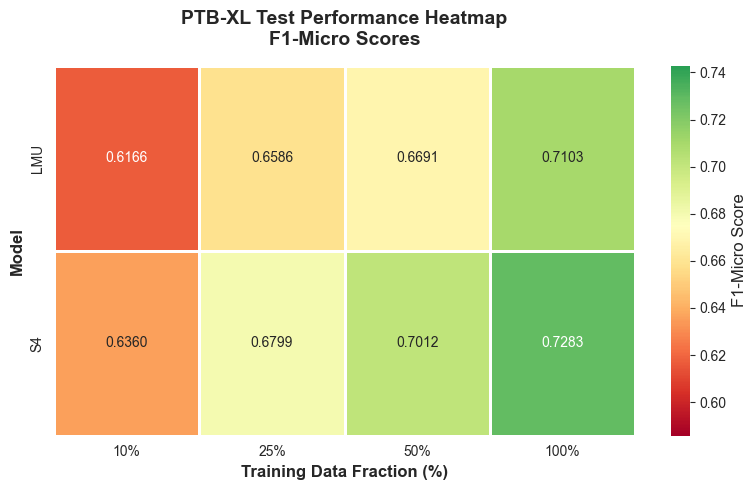

✅ Plot saved as: ptbxl_performance_heatmap.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

# Prepare data for heatmap
heatmap_data = pivot_data.T

# Create heatmap
sns.heatmap(heatmap_data,
            annot=True,
            fmt='.4f',
            cmap='RdYlGn',
            center=heatmap_data.mean().mean(),
            cbar_kws={'label': 'F1-Micro Score'},
            linewidths=1,
            linecolor='white',
            ax=ax,
            vmin=heatmap_data.min().min() * 0.95,
            vmax=heatmap_data.max().max() * 1.02)

ax.set_xlabel('Training Data Fraction (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
ax.set_title('PTB-XL Test Performance Heatmap\nF1-Micro Scores',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels([f'{int(float(x.get_text()))}%' for x in ax.get_xticklabels()])

plt.tight_layout()
plt.show()